In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Load Titanic dataset directly from the web
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Look at the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# How many rows and columns?
print("Shape:", df.shape)

# Any missing values?
print("\nMissing values:")
print(df.isnull().sum())

Shape: (891, 12)

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# Fill missing Age values with the average age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Drop the Cabin column (too many missing values)
df.drop(columns=['Cabin'], inplace=True)

# Drop rows where Embarked is missing
df.dropna(subset=['Embarked'], inplace=True)

# Convert Sex column to numbers (male=0, female=1)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Convert Embarked to numbers
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("Cleaned! Missing values now:")
print(df.isnull().sum())

Cleaned! Missing values now:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_806/644365360.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


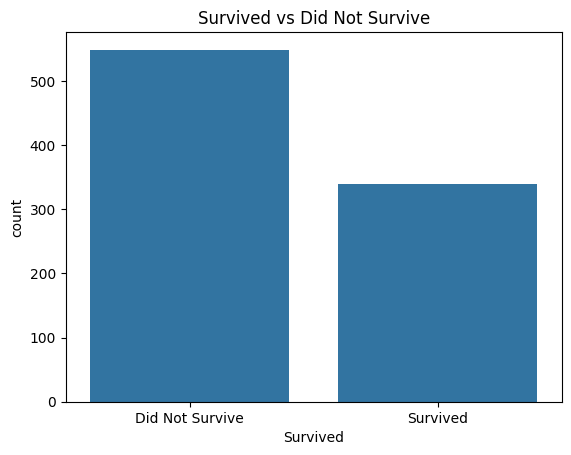

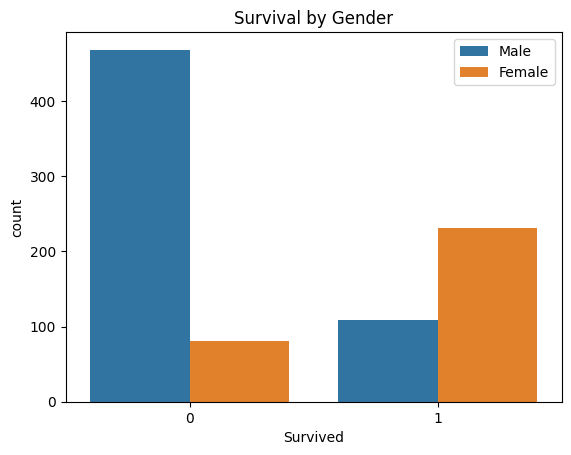

In [5]:
# How many survived vs died?
sns.countplot(x='Survived', data=df)
plt.title('Survived vs Did Not Survive')
plt.xticks([0,1], ['Did Not Survive', 'Survived'])
plt.show()

# Survival by gender
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival by Gender')
plt.legend(['Male', 'Female'])
plt.show()

In [6]:
# Choose the features (inputs) and target (what we predict)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Test the model
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 75.28%


In [7]:
# Predict survival for a new passenger
# (Pclass=3, Female, Age=25, no siblings, no parents, Fare=7.5, Embarked S)
new_passenger = pd.DataFrame([[3, 1, 25, 0, 0, 7.5, 0]], columns=features)
result = model.predict(new_passenger)

if result[0] == 1:
    print("This passenger would have SURVIVED 🟢")
else:
    print("This passenger would NOT have survived 🔴")

This passenger would have SURVIVED 🟢
